In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#sütun isimlerini ekliyoruz.
column_names = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Is_Churn']
df = pd.read_csv("churn_model_data.csv", header=None, names=column_names)

#veri setinin boyutuna ve kendisine bakıyoruz.
print("Yeni Veri Seti Boyutu:", df.shape)
display(df.head())
print("\n--- Güncel Veri Tipleri Kontrolü ---")
df.info()

Yeni Veri Seti Boyutu: (5878, 5)


,CustomerID,Recency,Frequency,Monetary,Is_Churn
0,13992,30,3,219.500002,0
1,14324,409,2,701.609996,1
2,15984,2,30,8636.619974,0
3,18237,2,5,987.100001,0
4,14656,169,5,814.649995,1



--- Güncel Veri Tipleri Kontrolü ---
<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  5878 non-null   int64  
 1   Recency     5878 non-null   int64  
 2   Frequency   5878 non-null   int64  
 3   Monetary    5878 non-null   float64
 4   Is_Churn    5878 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 229.7 KB


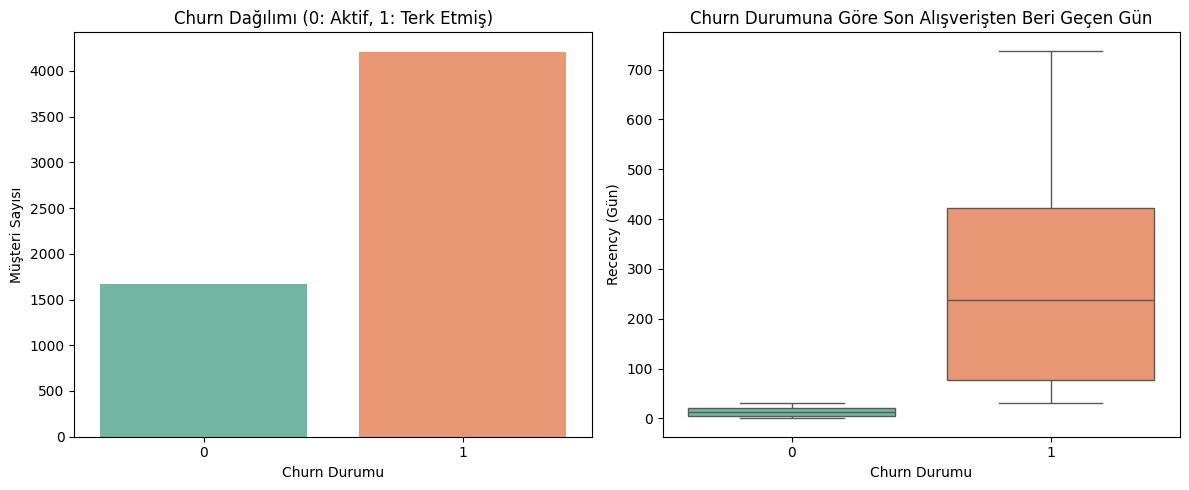

In [5]:
# Churn dağılımını görselleştirelim
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Is_Churn', data=df, palette='Set2', hue='Is_Churn', legend=False)
plt.title('Churn Dağılımı (0: Aktif, 1: Terk Etmiş)')
plt.xlabel('Churn Durumu')
plt.ylabel('Müşteri Sayısı')

# Recency vs Churn ilişkisi
plt.subplot(1, 2, 2)
sns.boxplot(x='Is_Churn', y='Recency', data=df, palette='Set2', hue='Is_Churn', legend=False)
plt.title('Churn Durumuna Göre Son Alışverişten Beri Geçen Gün')
plt.xlabel('Churn Durumu')
plt.ylabel('Recency (Gün)')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# Girdi özelliklerini (Features) ve hedefi (Target) seçiyoruz
X = df[['Frequency', 'Monetary']] 
y = df['Is_Churn']

# %80 Eğitim, %20 Test olacak şekilde bölüyoruz
# stratify=y parametresi iki sette de Churn oranının eşit dağılmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

Eğitim Seti Boyutu: (4702, 2)
Test Seti Boyutu: (1176, 2)


--- MODEL PERFORMANS RAPORU ---
              precision    recall  f1-score   support

           0       0.63      0.40      0.49       334
           1       0.79      0.91      0.85       842

    accuracy                           0.76      1176
   macro avg       0.71      0.66      0.67      1176
weighted avg       0.75      0.76      0.75      1176



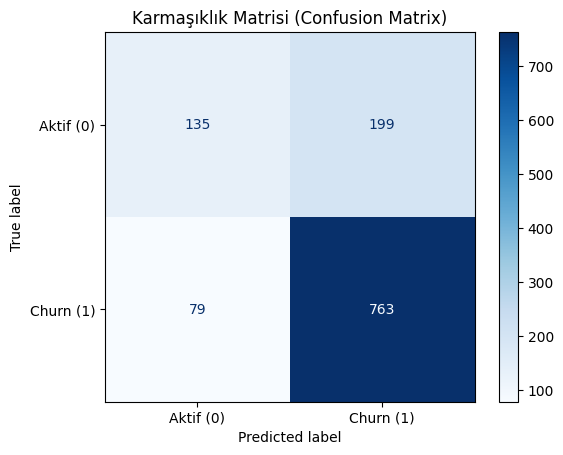

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Modeli tanımla ve eğit
model = XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# Test setiyle tahmin yap
y_pred = model.predict(X_test)

# Performans sonuçlarını yazdır
print("--- MODEL PERFORMANS RAPORU ---")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisini Çizdir
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aktif (0)', 'Churn (1)'])
disp.plot(cmap='Blues')
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.show()

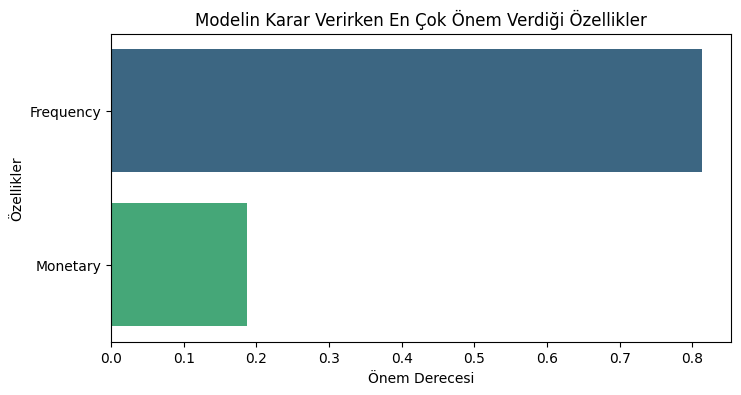

In [13]:
# Özellik önem derecelerini al
importances = model.feature_importances_
features = X.columns

# Grafikleştir
plt.figure(figsize=(8, 4))
# 'Viridis' yerine küçük harfle 'viridis' yaptık
sns.barplot(x=importances, y=features, palette='viridis', hue=features, legend=False) 
plt.title('Modelin Karar Verirken En Çok Önem Verdiği Özellikler')
plt.xlabel('Önem Derecesi')
plt.ylabel('Özellikler')
plt.show()